# Multi-tissue classification Stomach cancer

**Table of Contents**                                                                      
Step1: Environment Setup                                                                          
Step2: Data Loading and Preparation                                                                      
Step3: Analyzing Class Distribution                                                          
Step4: Data Augmentation                                                           
Step5: Splitting the Dataset                                                                                     
Step6: Preparing Data Generators                                                             
Step7: Building the Model                                                                                       
Step8: Compiling the Model                                                 
Step9: Implementing Learning Rate Scheduling and Early Stopping                                      
Step10: Training the Model                                                             
Step11: Evaluating the Model                                                                   
Step12: Conclusion and Next Steps                                                           



**Step: 1 Environment Setup**

In [1]:
# Data manipulation and analysis
import os 
os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import numpy as np
import pandas as pd
from glob import glob

# Image processing
from PIL import Image
import cv2


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, MaxPool2D
from tensorflow.keras.layers import Layer, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.layers import Input, Embedding, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import keras
from keras import layers
from keras import ops


# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Loading Data**


In [2]:
# Assuming the dataset is in a folder named 'dataset'
data_dir = '/kaggle/input/tcga-stomach-histological-images/stomach'

# Get class names from subdirectory names
classes = sorted([d.name for d in os.scandir(data_dir) if d.is_dir()])
print("Classes:", classes)


# Initialize lists to hold file paths and labels
image_paths = []
image_labels = []

# Map class names to numerical labels
class_to_label = {class_name: idx for idx, class_name in enumerate(classes)}
print("Class to label mapping:", class_to_label)

# Loop through each class directory and collect file paths
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    # Get all image file paths in the class directory
    image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith('.jpg')]
    # Append file paths and labels
    image_paths.extend(image_files)
    image_labels.extend([class_to_label[class_name]] * len(image_files))
    #print(f"Processing {len(image_files)} images for class '{class_name}'")

print(f"Total images found: {len(image_paths)}")

Classes: ['non-tumour', 'tumour']
Class to label mapping: {'non-tumour': 0, 'tumour': 1}
Total images found: 28899


**3. Analyzing Class Distribution**

Class counts:
 class_name
non-tumour    15372
tumour        13527
Name: count, dtype: int64


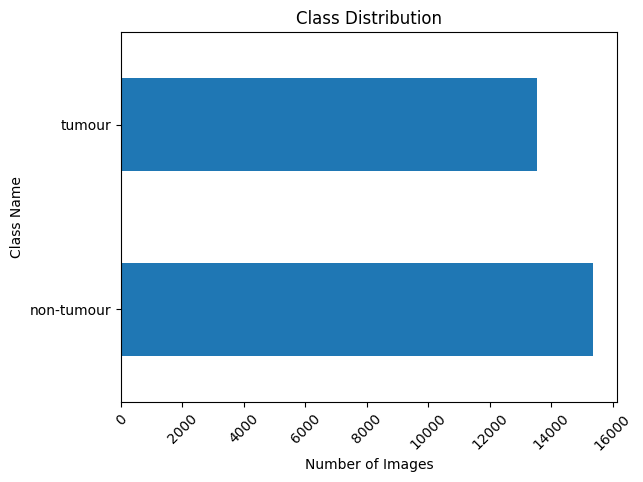

In [3]:
# Create a DataFrame to aid in analysis
df = pd.DataFrame({
    'image_path': image_paths,
    'label': image_labels
})

# Map numerical labels to class names
label_to_class = {v: k for k, v in class_to_label.items()}
df['class_name'] = df['label'].map(label_to_class)

# Display class counts
class_counts = df['class_name'].value_counts()
print("Class counts:\n", class_counts)

# Plot class distribution
class_counts.plot(kind='barh')
plt.title('Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.xticks(rotation=45)
plt.show() 



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28899 entries, 0 to 28898
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  28899 non-null  object
 1   label       28899 non-null  int64 
 2   class_name  28899 non-null  object
dtypes: int64(1), object(2)
memory usage: 677.4+ KB


In [5]:
df.head()

,image_path,label,class_name
0,/kaggle/input/tcga-stomach-histological-images...,0,non-tumour
1,/kaggle/input/tcga-stomach-histological-images...,0,non-tumour
2,/kaggle/input/tcga-stomach-histological-images...,0,non-tumour
3,/kaggle/input/tcga-stomach-histological-images...,0,non-tumour
4,/kaggle/input/tcga-stomach-histological-images...,0,non-tumour


In [6]:
df.tail()

,image_path,label,class_name
28894,/kaggle/input/tcga-stomach-histological-images...,1,tumour
28895,/kaggle/input/tcga-stomach-histological-images...,1,tumour
28896,/kaggle/input/tcga-stomach-histological-images...,1,tumour
28897,/kaggle/input/tcga-stomach-histological-images...,1,tumour
28898,/kaggle/input/tcga-stomach-histological-images...,1,tumour


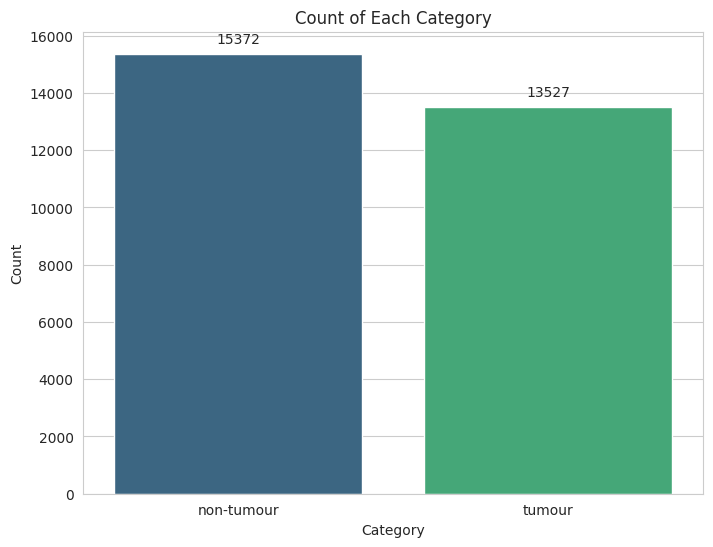

In [7]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x=df['label'].map(label_to_class), palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center',
                va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')

plt.title("Count of Each Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

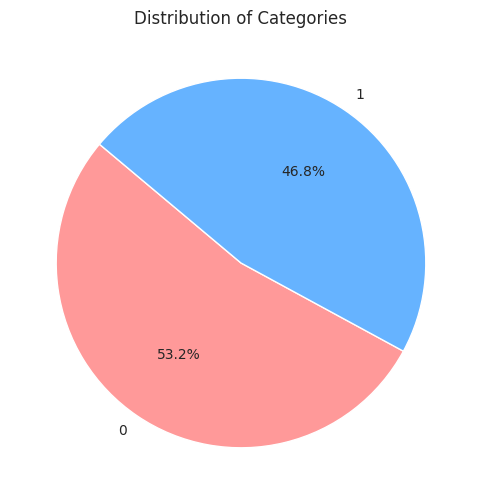

In [8]:
#Show distribution of classes in pye chart
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])

plt.title("Distribution of Categories")

plt.show() 

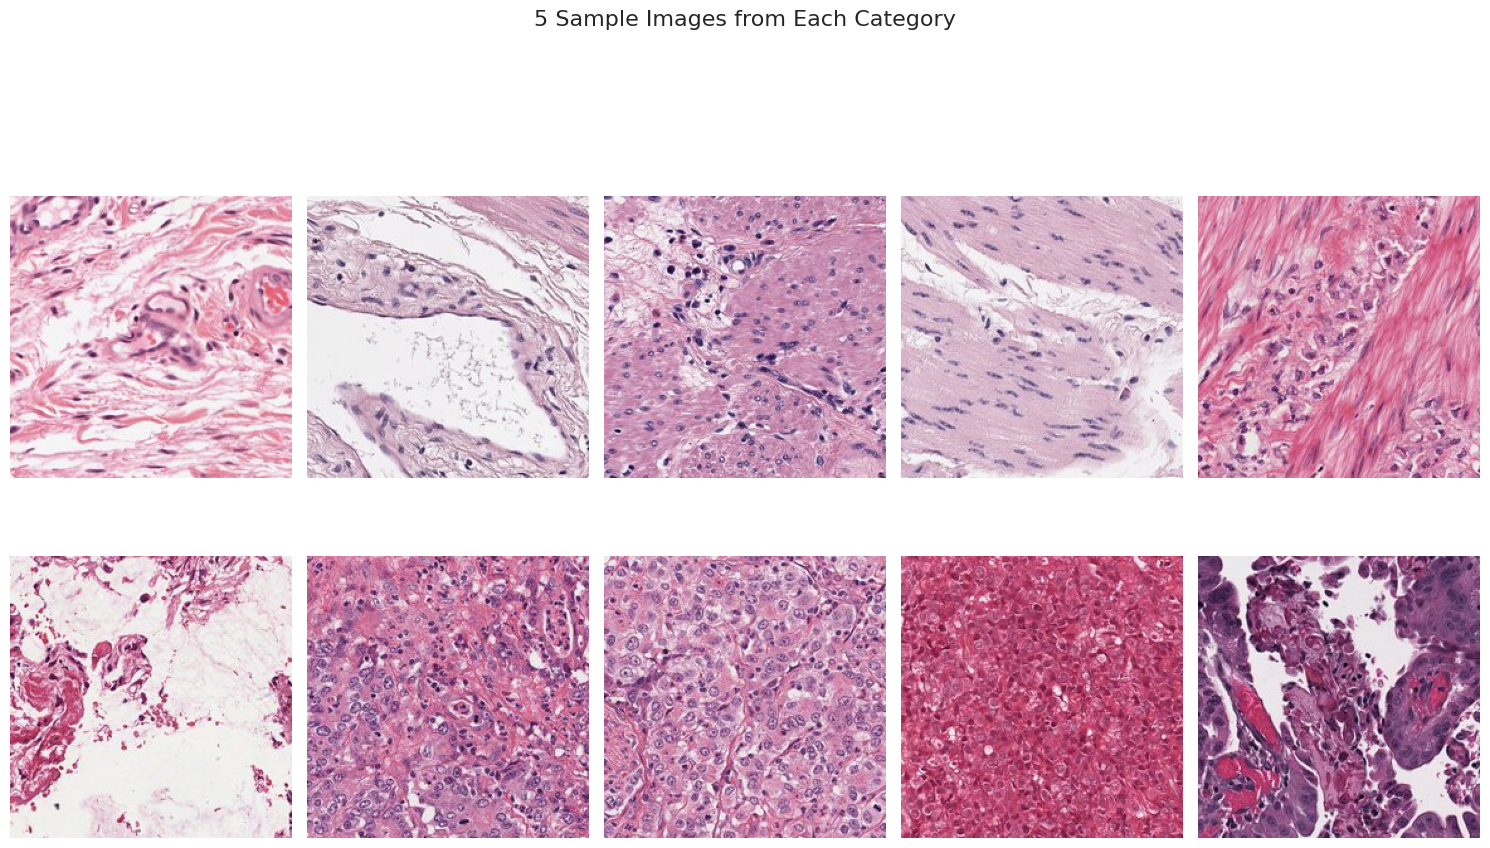

In [9]:
num_images = 5

fig, axes = plt.subplots(len(label_to_class), num_images, figsize=(15, 10))
fig.suptitle("5 Sample Images from Each Category", fontsize=16)

for i, category in enumerate(label_to_class):

    sample_images = df[df['label'] == category].sample(num_images) #random_state = 42

    for j, image_path in enumerate(sample_images['image_path']):

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(category, fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
     


**Step 5: Split the Dataset**


In [10]:
# Split into training 80% and temp 20% (validation 10% + test 10%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42,
    shuffle = True
)

# Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42,
    shuffle = True
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")





Training set size: 23119
Validation set size: 2890
Test set size: 2890


**6. Preparing Data Generators**


6.1. Training Data Generator


In [78]:
# Define image data generator with augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

# Load training and validation data
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 23119 validated image filenames belonging to 2 classes.


6.2. Validation Generator

In [80]:
val_gen = ImageDataGenerator(rescale=1./255)
validation_generator = val_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 2890 validated image filenames belonging to 2 classes.


In [81]:
# Evaluate the model using the test set
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
    )


Found 2890 validated image filenames belonging to 2 classes.


**Configure the hyperparameters**

In [86]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 256
num_epochs = 30  # For real training, use num_epochs=100. 10 is a test value
image_size = 224  # We'll resize input images to this size
patch_size = 18  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifier


**Implement multilayer perceptron (MLP)**

In [87]:
# Define the MLP function
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

**Implement patch creation as a layer**

In [88]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


Let's display patches for a sample image

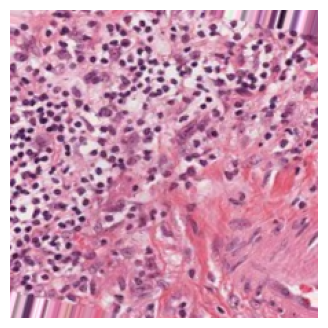

Image size: 224 X 224
Patch size: 18 X 18
Patches per image: 144
Elements per patch: 972


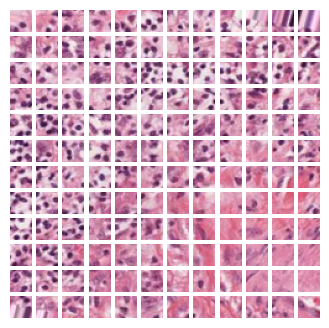

In [89]:
# Extract a batch of images
x_batch, y_batch = next(train_generator)

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

# Resize the image
resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_size, image_size)
)

# Extract patches from the resized image
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

# Display the patches
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy())
    plt.axis("off")
plt.show()


**Implement the patch encoding layer**

In [90]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config


**9. Building and Configuring the ViT Model**

In [91]:
input_shape = (224, 224, 3)
num_classes = 2  # Set this to the number of classes in your dataset
# Create the Vision Transformer model
inputs = keras.Input(shape=input_shape)
 # Create patches
patches = Patches(patch_size)(inputs)
 # Encode patches
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

 # Create multiple layers of the Transformer block
for _ in range(transformer_layers):
    # Layer normalization 1
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    # Multi-head attention layer
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)
    # Skip connection 1
    x2 = layers.Add()([attention_output, encoded_patches])
    # Layer normalization 2
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    # MLP
    x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
    # Skip connection 2
    encoded_patches = layers.Add()([x3, x2])
 # Create a [batch_size, projection_dim] tensor
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)
# Add MLP
features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
# Classify outputs
logits = layers.Dense(num_classes)(features)
# Create the Keras model
model = keras.Model(inputs=inputs, outputs=logits)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patches_14 (Patches)      │ (None, 144, 972)       │              0 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_encoder_4           │ (None, 144, 64)        │         71,488 │ patches_14[0][0]       │
│ (PatchEncoder)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_68    │ (None, 144, 64)        │            128 │ patch_encoder_4[0][0]  │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_32   │ (None, 144, 64)        │         66,368 │ layer_normalization_6… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_64 (Add)              │ (None, 144, 64)        │              0 │ multi_head_attention_… │
│                           │                        │                │ patch_encoder_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_69    │ (None, 144, 64)        │            128 │ add_64[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_81 (Dense)          │ (None, 144, 128)       │          8,320 │ layer_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_109 (Dropout)     │ (None, 144, 128)       │              0 │ dense_81[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_82 (Dense)          │ (None, 144, 64)        │          8,256 │ dropout_109[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_110 (Dropout)     │ (None, 144, 64)        │              0 │ dense_82[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_65 (Add)              │ (None, 144, 64)        │              0 │ dropout_110[0][0],     │
│                           │                        │                │ add_64[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_70    │ (None, 144, 64)        │            128 │ add_65[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_33   │ (None, 144, 64)        │         66,368 │ layer_normalization_7… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_66 (Add)              │ (None, 144, 64)        │              0 │ multi_head_attention_… │
│                      

 Total params: 21,713,858 (82.83 MB)

 Trainable params: 21,713,858 (82.83 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            
        ],
)
    
checkpoint_filepath = "/kaggle/working/checkpoint.weights.h5"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    
    checkpoint_filepath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True
)


In [ ]:
history = model.fit( 
        train_generator,
        batch_size=batch_size,
        validation_data=validation_generator,
        epochs=num_epochs,
        callbacks=[checkpoint_callback]
)              

Epoch 1/30
722/723 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5436 - loss: 1.8907

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


723/723 ━━━━━━━━━━━━━━━━━━━━ 319s 428ms/step - accuracy: 0.5437 - loss: 1.8882 - val_accuracy: 0.6260 - val_loss: 0.6240
Epoch 2/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 268s 363ms/step - accuracy: 0.6533 - loss: 0.6265 - val_accuracy: 0.6827 - val_loss: 0.6502
Epoch 3/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 258s 357ms/step - accuracy: 0.6764 - loss: 0.5895 - val_accuracy: 0.7021 - val_loss: 0.5433
Epoch 4/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 258s 356ms/step - accuracy: 0.7016 - loss: 0.5582 - val_accuracy: 0.7156 - val_loss: 0.5466
Epoch 5/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 257s 354ms/step - accuracy: 0.7192 - loss: 0.5464 - val_accuracy: 0.7308 - val_loss: 0.5358
Epoch 6/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 257s 354ms/step - accuracy: 0.7328 - loss: 0.5295 - val_accuracy: 0.7685 - val_loss: 0.4922
Epoch 7/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 256s 354ms/step - accuracy: 0.7502 - loss: 0.5168 - val_accuracy: 0.7820 - val_loss: 0.4936
Epoch 8/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 256s 353ms/step - accuracy: 0.7867 - loss: 0.47

In [100]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9276 - loss: 0.2285
Test Accuracy: 92.53%


In [101]:
test_labels = test_generator.classes
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
     

report = classification_report(test_labels, predicted_classes, target_names=list(test_generator.class_indices.keys()))
print(report)
     


91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step
              precision    recall  f1-score   support

  non-tumour       0.52      0.53      0.53      1538
      tumour       0.45      0.44      0.45      1352

    accuracy                           0.49      2890
   macro avg       0.49      0.49      0.49      2890
weighted avg       0.49      0.49      0.49      2890



In [103]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

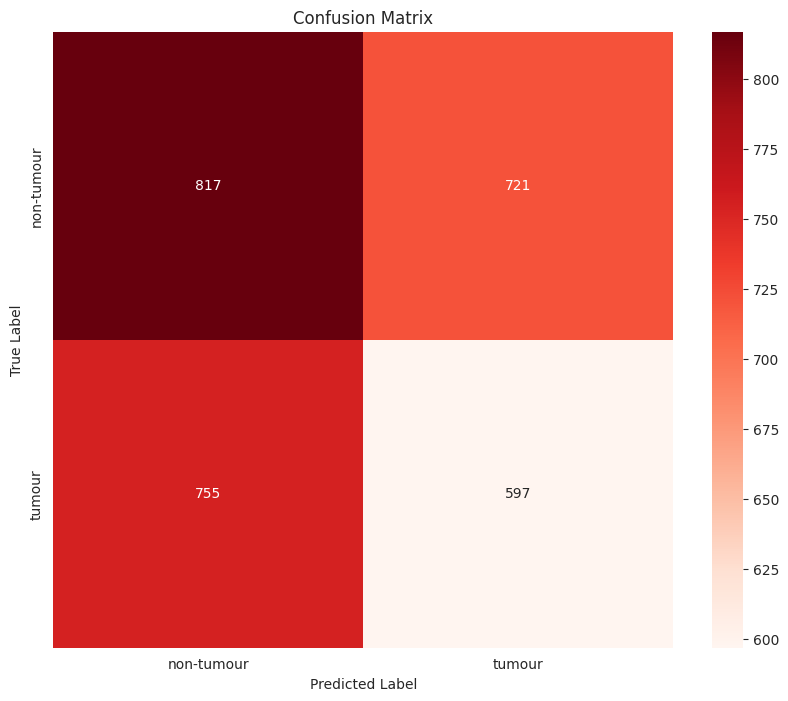

In [104]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=list(test_generator.class_indices.keys()), yticklabels=list(test_generator.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [73]:
vit_classifier.save('model.h5')
vit_classifier.save('model.keras')